# Pre processamento

## Imports e caminhos

In [113]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_src = "./img/dog.jpg"

## 1. Carrega a imagem

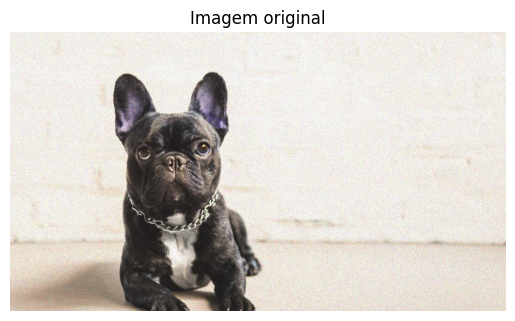

In [114]:
# Carrega a Imagem

# Original
img = cv2.imread(img_src)

# Mostra a Imagem original
plt.imshow(img)
plt.title("Imagem original")
plt.axis('off')
plt.show()


## 2. Aplica o grayscale

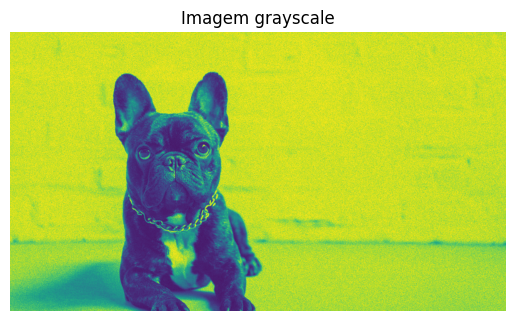

In [115]:
# imread retorna em BGR
# Formula padrão da luminencia: 0.299R + 0.587G + 0.114B
# img[:,:,:] = linha, coluna, canal

img = (
    0.299 * img[:,:,2] +
    0.587 * img[:,:,1] +
    0.114 * img[:,:,0]
)

# Mostra a Imagem com grayscale
plt.imshow(img)
plt.title("Imagem grayscale")
plt.axis('off')
plt.show()

## 3. Aplica o padding na imagem 

In [116]:
# adiciona 0s ao redor da imagem

padded = np.pad(img, pad_width=1, mode='constant')

## 4. Convulção

In [117]:
def convolve(image, kernel):
    height, width = img.shape
    k_height, k_width = kernel.shape

    pad_h = k_height // 2
    pad_w = k_width // 2

    padded = np.pad(image, pad_width=((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros((height, width))

    for y in range(height):
        for x in range(width):

            region = padded[y:y+k_height, x:x+k_width]
            value = np.sum(region * kernel)

            output[y, x] = value
        
    return output

## 5. Blur

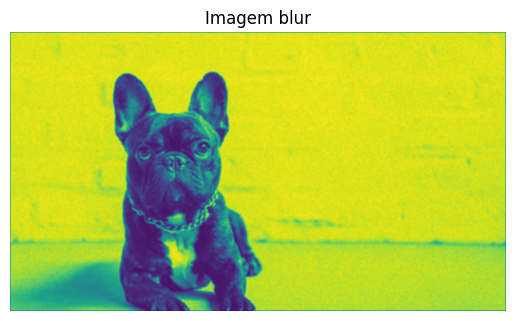

In [118]:
img = img.astype(np.float32)

k_size = 5

blur_kernel = np.ones((k_size, k_size)) / (k_size * k_size)

img = convolve(img, blur_kernel)

# Mostra a Imagem com blur
plt.imshow(img)
plt.title("Imagem blur")
plt.axis('off')
plt.show()

## 6. Sobel

In [119]:
# medir variação horizontal e vertical na imagem

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

gx = convolve(img, sobel_x)
gy = convolve(img, sobel_y)

## 7. Magnitude e Threshold

Formula da magnitude

$$
g = \sqrt{g_x^2 + g_y^2}
$$


0.006285728613308904
786.0891804833134
22.978873841728543


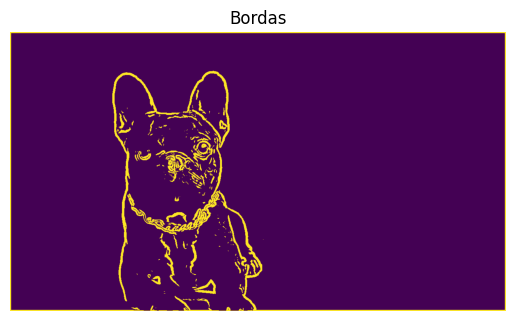

In [ ]:
magnitude = np.sqrt(gx**2 + gy**2)

edges = np.where(magnitude > 85, 255, 0)

plt.imshow(edges)
plt.title("Bordas")
plt.axis('off')
plt.savefig("./img/dog_processed.png")
plt.show()